# Étapes 1 & 2 — Acquisition des données et Prétraitement des images

Ce notebook couvre :
1. **Acquisition des données** : chargement de la base *Labeled Faces in the Wild* (LFW) via `scikit-learn`, exploration du format des données (résolution, annotations).
2. **Prétraitement des images** :
   - Conversion en niveaux de gris
   - Normalisation des valeurs de pixels
   - Redimensionnement
   - Détection et cadrage des visages (Viola-Jones / Haar Cascade)
   - Alignement des visages par détection des yeux
   - Réduction du bruit et correction de l'éclairage (CLAHE)


## 0. Imports et configuration

In [4]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2

from sklearn.datasets import fetch_lfw_people

# ── Matplotlib defaults ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"OpenCV   : {cv2.__version__}")
print(f"NumPy    : {np.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")

OpenCV   : 4.13.0
NumPy    : 2.3.5
Matplotlib: 3.10.6


---
## Étape 1 — Acquisition des données

Nous utilisons la base **Labeled Faces in the Wild (LFW)**, une référence publique contenant des photos de personnalités publiques annotées avec leurs noms.

- **Source** : http://vis-www.cs.umass.edu/lfw/
- **Format** : images JPEG 250×250 pixels (couleur RGB)
- **Annotations** : nom de la personne (label de classe)
- **Chargement** : `sklearn.datasets.fetch_lfw_people` (téléchargement automatique, ~200 Mo)

In [5]:
# ── Chargement de LFW ─────────────────────────────────────────────────────────
# min_faces_per_person=20 : on ne conserve que les individus ayant au moins
# 20 images pour disposer d'un ensemble suffisant d'exemples par classe.
# color=True             : images en couleur (3 canaux RGB).
# resize=1.0             : on garde la résolution d'origine (250×250).

print("Chargement du dataset LFW (peut prendre quelques secondes)…")
lfw = fetch_lfw_people(
    min_faces_per_person=20,
    color=True,
    resize=1.0,
    data_home=os.path.join('.', 'data'),  # cache local dans le dossier data/
)
print("Dataset chargé !")

Chargement du dataset LFW (peut prendre quelques secondes)…
Dataset chargé !


In [6]:
# ── Exploration du format des données ─────────────────────────────────────────
images  = lfw.images          # tableau (N, H, W, 3) float32 normalisé [0, 1]
labels  = lfw.target          # entiers 0..n_classes-1
names   = lfw.target_names    # tableau des noms (str)

N, H, W, C = images.shape
n_classes   = len(names)

print(f"Nombre d'images     : {N}")
print(f"Résolution          : {H}×{W} pixels")
print(f"Nombre de canaux    : {C}  (RGB)")
print(f"Nombre d'identités  : {n_classes}")
print(f"Type / plage valeurs: {images.dtype}, min={images.min():.2f}, max={images.max():.2f}")

Nombre d'images     : 3023
Résolution          : 125×94 pixels
Nombre de canaux    : 3  (RGB)
Nombre d'identités  : 62
Type / plage valeurs: float32, min=0.00, max=1.00


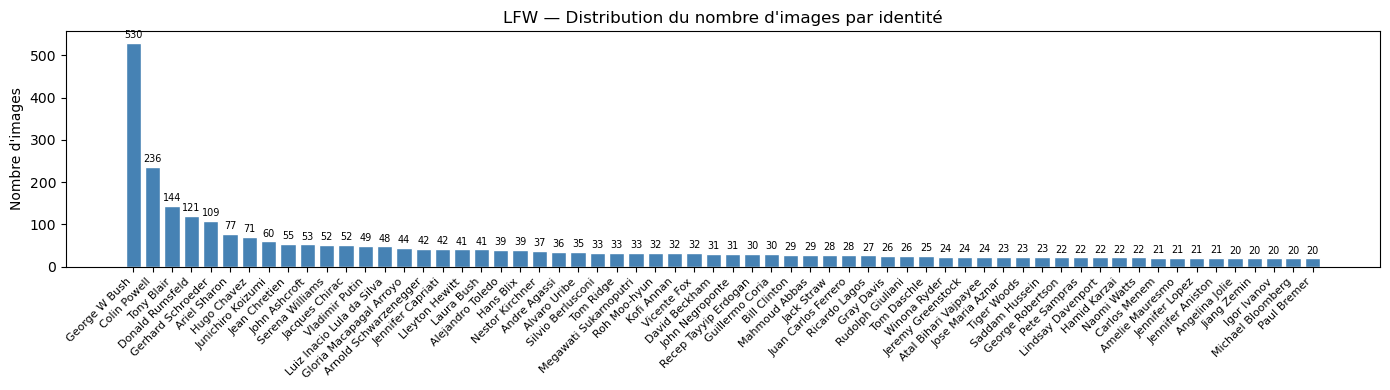


Personne la plus représentée : George W Bush (530 images)
Personnes les moins représentées : 20 images


In [7]:
# ── Distribution du nombre d'images par personne ─────────────────────────────
from collections import Counter

counts = Counter(labels)
sorted_names  = [names[i] for i in sorted(counts, key=counts.get, reverse=True)]
sorted_counts = [counts[i] for i in sorted(counts, key=counts.get, reverse=True)]

fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(range(len(sorted_names)), sorted_counts, color='steelblue', edgecolor='white')
ax.set_xticks(range(len(sorted_names)))
ax.set_xticklabels(sorted_names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Nombre d'images")
ax.set_title("LFW — Distribution du nombre d'images par identité")
ax.bar_label(bars, padding=2, fontsize=7)
plt.tight_layout()
plt.show()

print(f"\nPersonne la plus représentée : {sorted_names[0]} ({sorted_counts[0]} images)")
print(f"Personnes les moins représentées : {sorted_counts[-1]} images")

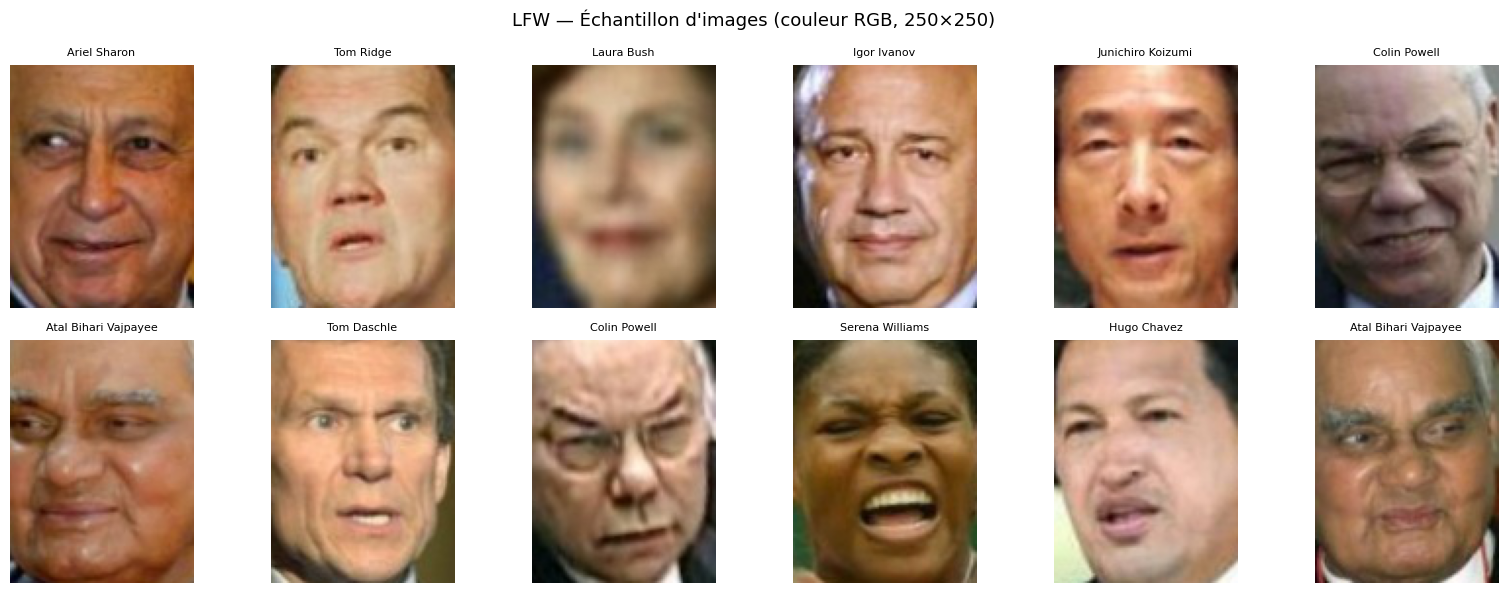

In [8]:
# ── Affichage d'un échantillon d'images avec leurs annotations ────────────────
# On choisit aléatoirement 12 images pour illustrer la diversité du dataset.

n_show = 12
rng    = np.random.default_rng(RANDOM_STATE)
idx    = rng.choice(N, n_show, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle("LFW — Échantillon d'images (couleur RGB, 250×250)", fontsize=13)

for ax, i in zip(axes.ravel(), idx):
    ax.imshow(images[i])          # images LFW sont déjà en RGB [0,1]
    ax.set_title(names[labels[i]], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## Étape 2 — Prétraitement des images

Pour que les modèles de reconnaissance fonctionnent de manière robuste, les images brutes doivent être normalisées. Les étapes ci-dessous sont appliquées successivement.

> **Remarque** : LFW fournit les images en `float32` dans `[0, 1]`. Pour les opérations OpenCV, on reconvertit en `uint8` (`[0, 255]`) quand nécessaire.

In [9]:
# ── Fonctions utilitaires communes ────────────────────────────────────────────

def lfw_to_bgr(img_rgb_float):
    """Convertit une image LFW (RGB float32 [0,1]) → BGR uint8 [0,255]."""
    img_uint8 = (img_rgb_float * 255).clip(0, 255).astype(np.uint8)
    return cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)

def bgr_to_rgb(img):
    """Convertit BGR → RGB pour l'affichage matplotlib."""
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# On travaille sur un sous-ensemble fixe pour les démonstrations
DEMO_IDX = 0  # indice dans le dataset LFW
demo_rgb_float = images[DEMO_IDX]                       # RGB float [0,1]
demo_bgr       = lfw_to_bgr(demo_rgb_float)             # BGR uint8 [0,255]
demo_name      = names[labels[DEMO_IDX]]

print(f"Image de démonstration : {demo_name}")
print(f"Forme : {demo_bgr.shape}, dtype : {demo_bgr.dtype}")

Image de démonstration : Winona Ryder
Forme : (125, 94, 3), dtype : uint8


### 2a. Conversion en niveaux de gris

La conversion en niveaux de gris réduit la dimensionnalité de 3 canaux à 1, ce qui accélère le traitement tout en conservant l'information de structure essentielle à la reconnaissance.

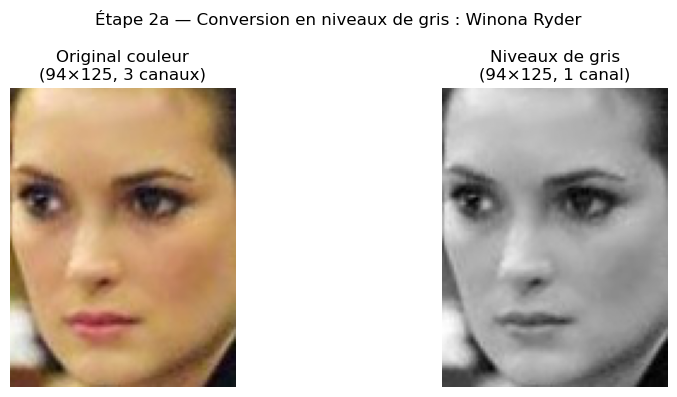

Réduction de la taille : 35250 octets → 11750 octets (facteur 3×)


In [10]:
# ── Conversion BGR → niveaux de gris ─────────────────────────────────────────
# cv2.COLOR_BGR2GRAY applique la pondération perceptuelle :
#   Y = 0.114·B + 0.587·G + 0.299·R
demo_gray = cv2.cvtColor(demo_bgr, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(bgr_to_rgb(demo_bgr))
axes[0].set_title(f"Original couleur\n({demo_bgr.shape[1]}×{demo_bgr.shape[0]}, 3 canaux)")
axes[0].axis('off')

axes[1].imshow(demo_gray, cmap='gray')
axes[1].set_title(f"Niveaux de gris\n({demo_gray.shape[1]}×{demo_gray.shape[0]}, 1 canal)")
axes[1].axis('off')

fig.suptitle(f"Étape 2a — Conversion en niveaux de gris : {demo_name}", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Réduction de la taille : {demo_bgr.nbytes} octets → {demo_gray.nbytes} octets "
      f"(facteur {demo_bgr.nbytes // demo_gray.nbytes}×)")

### 2b. Normalisation des valeurs de pixels

On ramène les valeurs de pixels depuis `[0, 255]` vers `[0, 1]` (float32). Cette étape améliore la convergence des modèles de ML en évitant les grandes disparités d'échelle entre les features.

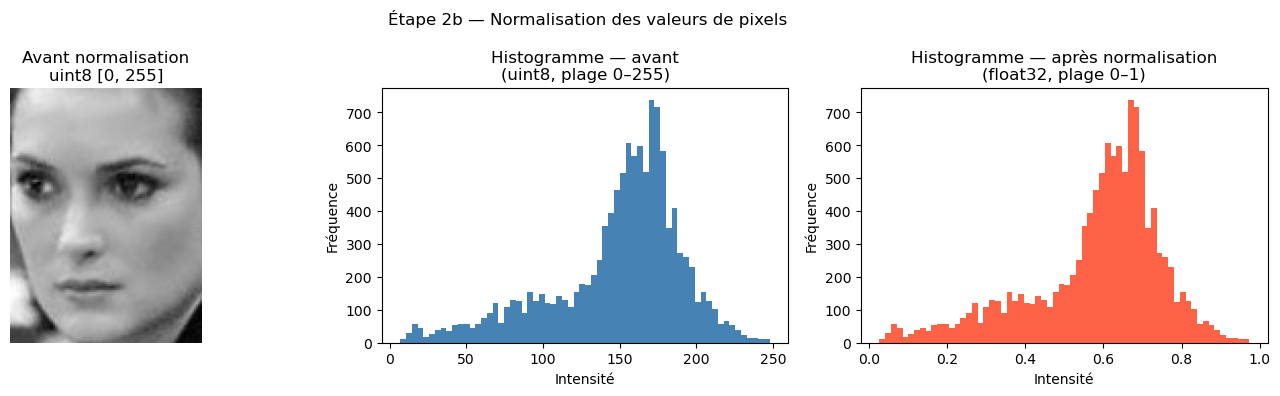

Avant : dtype=uint8, min=7, max=248
Après : dtype=float32, min=0.0275, max=0.9725


In [11]:
# ── Normalisation : [0,255] uint8 → [0,1] float32 ────────────────────────────
demo_norm = demo_gray.astype(np.float32) / 255.0

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Image avant normalisation
axes[0].imshow(demo_gray, cmap='gray')
axes[0].set_title("Avant normalisation\nuint8 [0, 255]")
axes[0].axis('off')

# Histogramme avant
axes[1].hist(demo_gray.ravel(), bins=64, color='steelblue', edgecolor='none')
axes[1].set_title("Histogramme — avant\n(uint8, plage 0–255)")
axes[1].set_xlabel("Intensité")
axes[1].set_ylabel("Fréquence")

# Histogramme après
axes[2].hist(demo_norm.ravel(), bins=64, color='tomato', edgecolor='none')
axes[2].set_title("Histogramme — après normalisation\n(float32, plage 0–1)")
axes[2].set_xlabel("Intensité")
axes[2].set_ylabel("Fréquence")

fig.suptitle("Étape 2b — Normalisation des valeurs de pixels", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Avant : dtype={demo_gray.dtype}, min={demo_gray.min()}, max={demo_gray.max()}")
print(f"Après : dtype={demo_norm.dtype}, min={demo_norm.min():.4f}, max={demo_norm.max():.4f}")

### 2c. Redimensionnement des images

Les modèles exigent une entrée de taille fixe. Nous redimensionnons à **128×128** pixels (taille utilisée dans le reste du projet).

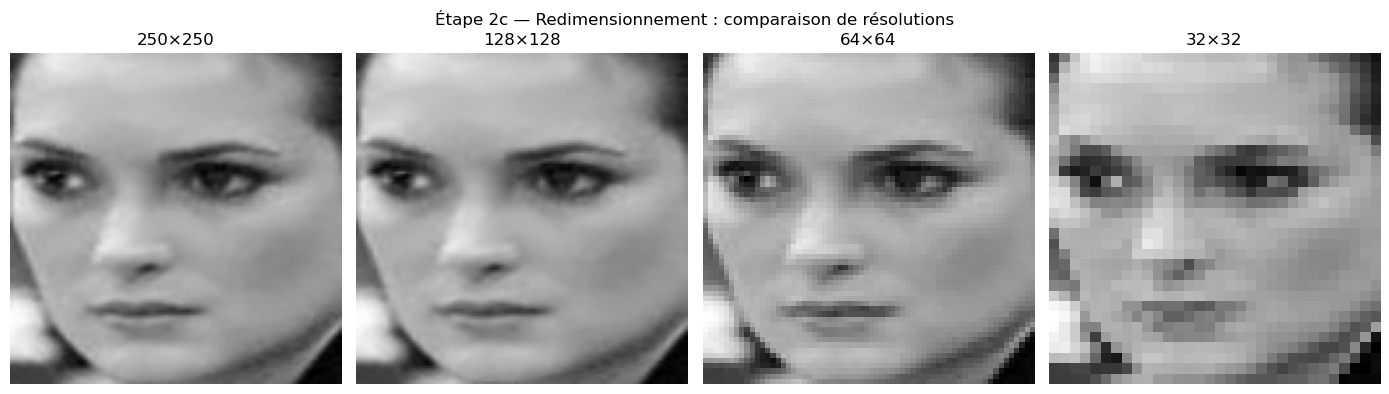

Taille d'entrée : (125, 94)
Taille de sortie cible : (128, 128)


In [12]:
# ── Redimensionnement bilinéaire ──────────────────────────────────────────────
TARGET_SIZE = (128, 128)  # (largeur, hauteur) — convention OpenCV

demo_resized = cv2.resize(demo_gray, TARGET_SIZE, interpolation=cv2.INTER_LINEAR)

sizes_to_compare = [(250, 250), (128, 128), (64, 64), (32, 32)]

fig, axes = plt.subplots(1, len(sizes_to_compare), figsize=(14, 4))
for ax, (w, h) in zip(axes, sizes_to_compare):
    resized = cv2.resize(demo_gray, (w, h), interpolation=cv2.INTER_LINEAR)
    ax.imshow(resized, cmap='gray')
    ax.set_title(f"{w}×{h}")
    ax.axis('off')

fig.suptitle("Étape 2c — Redimensionnement : comparaison de résolutions", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Taille d'entrée : {demo_gray.shape}")
print(f"Taille de sortie cible : {demo_resized.shape}")

### 2d. Détection et cadrage des visages — algorithme Viola-Jones (Haar Cascade)

L'algorithme **Viola-Jones** utilise des *features Haar* (différences de sommes sur des régions rectangulaires) et un classifieur *Adaboost* en cascade pour détecter les visages de façon rapide.

OpenCV fournit des modèles pré-entraînés au format XML.

Modèle chargé : C:\Users\seif\anaconda3\Lib\site-packages\cv2\data\haarcascade_frontalface_default.xml


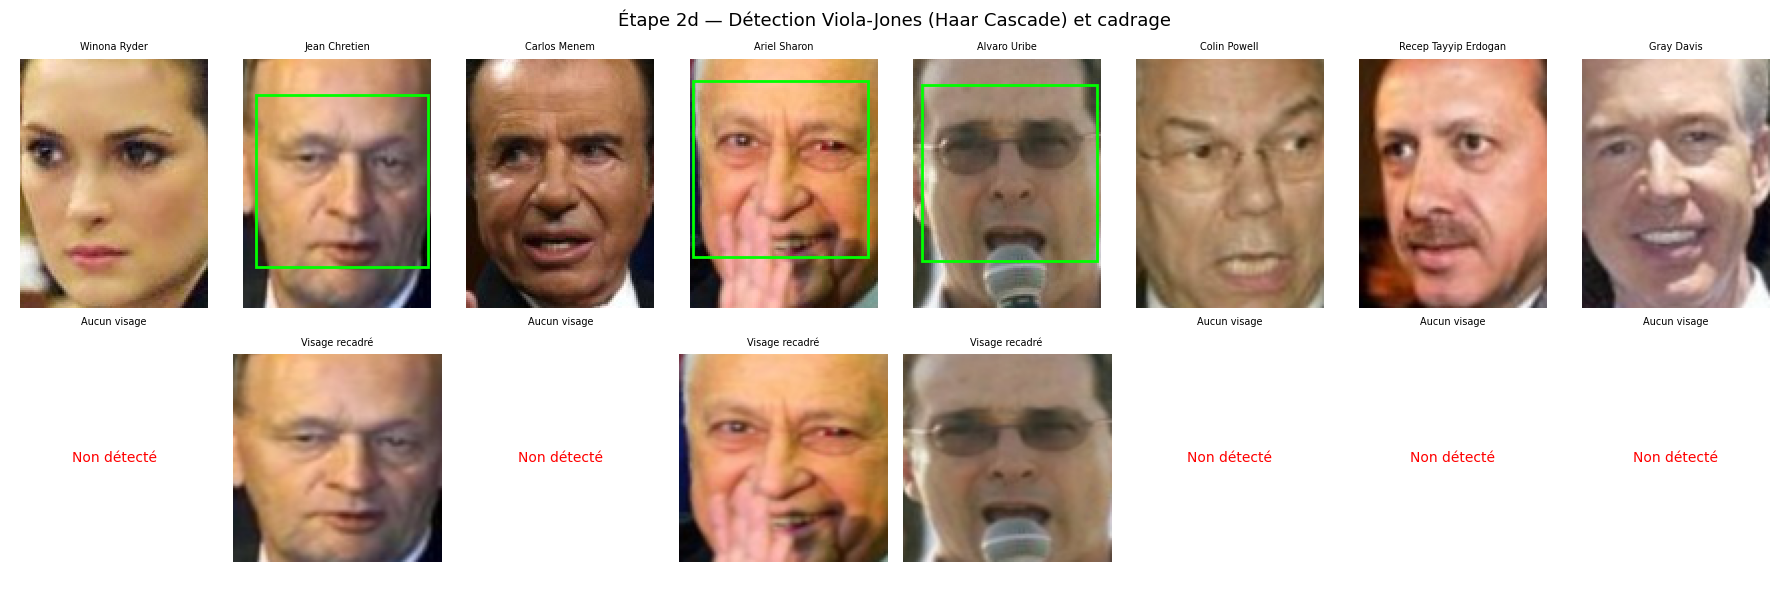

In [13]:
# ── Chargement du classifieur Haar Cascade ────────────────────────────────────
haar_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(haar_path)

assert not face_cascade.empty(), f"Impossible de charger le modèle depuis : {haar_path}"
print(f"Modèle chargé : {haar_path}")


def detect_and_crop_face(bgr_img, margin=0.2):
    """
    Détecte le plus grand visage dans *bgr_img* et retourne le recadrage
    avec une marge fractionnaire autour de la boîte englobante.

    Retourne (face_crop_bgr, bbox) ou (None, None) si aucun visage détecté.
    """
    gray = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30),
        flags=cv2.CASCADE_SCALE_IMAGE,
    )
    if len(faces) == 0:
        return None, None

    # On garde le plus grand visage (aire = w×h)
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])

    h_img, w_img = bgr_img.shape[:2]
    pad_x = int(w * margin)
    pad_y = int(h * margin)
    x1 = max(0, x - pad_x)
    y1 = max(0, y - pad_y)
    x2 = min(w_img, x + w + pad_x)
    y2 = min(h_img, y + h + pad_y)

    return bgr_img[y1:y2, x1:x2], (x, y, w, h)


# ── Démonstration sur plusieurs images ───────────────────────────────────────
n_demo = 8
demo_indices = list(range(n_demo))

fig, axes = plt.subplots(2, n_demo, figsize=(18, 6))
fig.suptitle("Étape 2d — Détection Viola-Jones (Haar Cascade) et cadrage", fontsize=13)

for col, idx in enumerate(demo_indices):
    bgr = lfw_to_bgr(images[idx])
    face_crop, bbox = detect_and_crop_face(bgr)

    # Ligne du haut : image originale + boîte englobante
    annotated = bgr_to_rgb(bgr.copy())
    ax_top = axes[0, col]
    ax_top.imshow(annotated)
    if bbox is not None:
        x, y, w, h = bbox
        rect = mpatches.Rectangle((x, y), w, h,
                                   linewidth=2, edgecolor='lime', facecolor='none')
        ax_top.add_patch(rect)
    ax_top.set_title(names[labels[idx]], fontsize=7)
    ax_top.axis('off')

    # Ligne du bas : recadrage du visage
    ax_bot = axes[1, col]
    if face_crop is not None:
        face_resized = cv2.resize(face_crop, (96, 96))
        ax_bot.imshow(bgr_to_rgb(face_resized))
        ax_bot.set_title("Visage recadré", fontsize=7)
    else:
        ax_bot.text(0.5, 0.5, 'Non détecté', ha='center', va='center', color='red')
        ax_bot.set_title("Aucun visage", fontsize=7)
    ax_bot.axis('off')

plt.tight_layout()
plt.show()

In [14]:
# ── Statistiques de détection sur tout le dataset ────────────────────────────
detected = 0
for img_rgb in images:
    bgr = lfw_to_bgr(img_rgb)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
    )
    if len(faces) > 0:
        detected += 1

rate = detected / N * 100
print(f"Taux de détection Viola-Jones sur LFW : {detected}/{N} ({rate:.1f} %)")

Taux de détection Viola-Jones sur LFW : 869/3023 (28.7 %)


### 2e. Alignement et correction des visages

Les variations d'orientation en roulis (*roll*) dégradent les performances des modèles. On corrige en :
1. Détectant les yeux grâce au classifieur Haar dédié.
2. Calculant l'angle entre les deux yeux.
3. Appliquant une rotation affine pour aligner les yeux horizontalement.

Classifieur yeux chargé : True


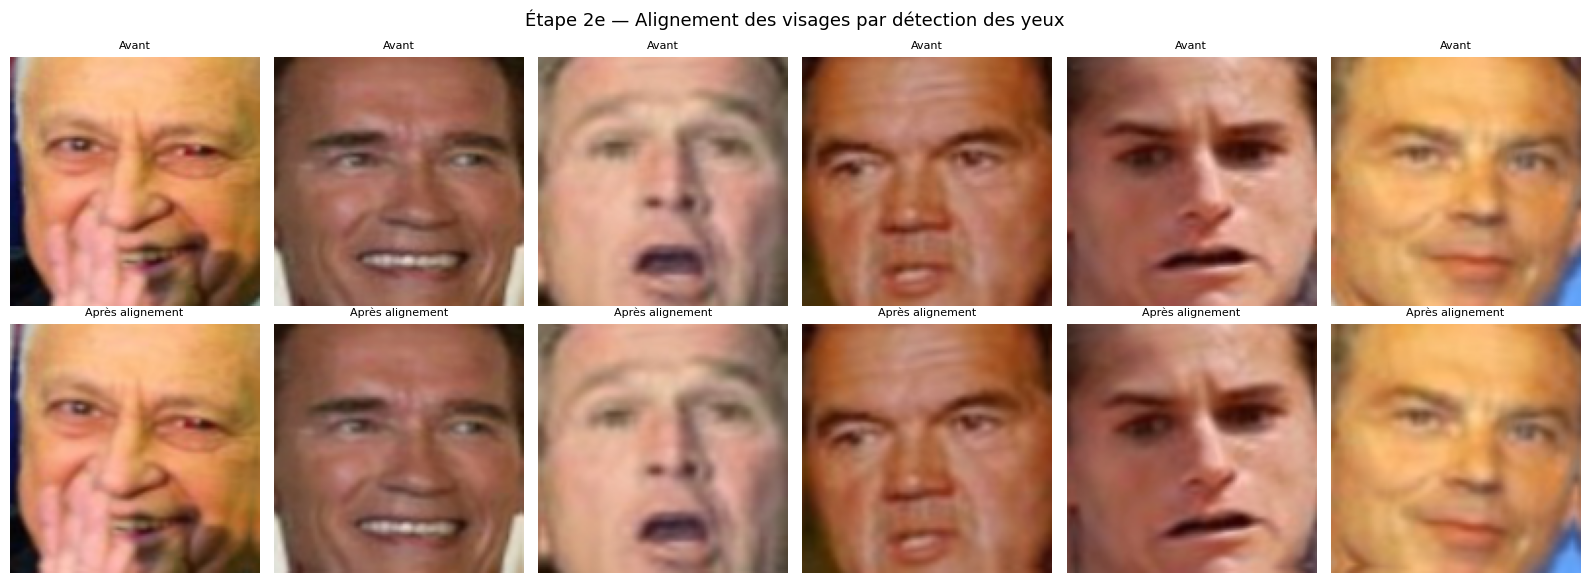

In [15]:
# ── Chargement du classifieur des yeux ────────────────────────────────────────
eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_eye.xml'
)
print(f"Classifieur yeux chargé : {not eye_cascade.empty()}")


def align_face(bgr_img, eye_cascade):
    gray = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    eyes = eye_cascade.detectMultiScale(
        gray,
        scaleFactor=1.05,
        minNeighbors=6,
        minSize=(25, 25)
    )

    # Not enough detections
    if len(eyes) < 2:
        return bgr_img

    # Keep only eyes in upper region (very important)
    eyes = [e for e in eyes if e[1] < h * 0.6]

    if len(eyes) < 2:
        return bgr_img

    #Select best pair (most horizontal alignment)
    best_pair = None
    min_dy = float('inf')

    for i in range(len(eyes)):
        for j in range(i + 1, len(eyes)):
            (x1, y1, w1, h1) = eyes[i]
            (x2, y2, w2, h2) = eyes[j]

            cy1 = y1 + h1 // 2
            cy2 = y2 + h2 // 2

            dy = abs(cy1 - cy2)

            if dy < min_dy:
                min_dy = dy
                best_pair = (eyes[i], eyes[j])

    if best_pair is None:
        return bgr_img

    # Sort LEFT → RIGHT
    eyes = sorted(best_pair, key=lambda e: e[0])
    left_eye, right_eye = eyes

    # Eye centers
    cx1 = left_eye[0] + left_eye[2] // 2
    cy1 = left_eye[1] + left_eye[3] // 2
    cx2 = right_eye[0] + right_eye[2] // 2
    cy2 = right_eye[1] + right_eye[3] // 2

    # Compute angle
    angle = np.degrees(np.arctan2(cy2 - cy1, cx2 - cx1))
    angle = -angle
    angle = float(angle)

    # Safety: avoid crazy rotations
    if abs(angle) > 30:
        return bgr_img

    # Rotation center
    center = (float(cx1 + cx2) / 2, float(cy1 + cy2) / 2)

    # Rotation
    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    aligned = cv2.warpAffine(
        bgr_img,
        M,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101
    )

    return aligned


# ── Démonstration d'alignement ────────────────────────────────────────────────
n_demo_align = 6
fig, axes = plt.subplots(2, n_demo_align, figsize=(16, 6))
fig.suptitle("Étape 2e — Alignement des visages par détection des yeux", fontsize=13)

col = 0
for idx in range(N):
    if col >= n_demo_align:
        break
    bgr = lfw_to_bgr(images[idx])
    face_crop, _ = detect_and_crop_face(bgr)
    if face_crop is None:
        continue

    face_crop = cv2.resize(face_crop, (128, 128))
    aligned   = align_face(face_crop, eye_cascade)

    # Ne montrer que les images où l'alignement a réellement modifié l'image
    if np.array_equal(face_crop, aligned):
        continue

    axes[0, col].imshow(bgr_to_rgb(face_crop))
    axes[0, col].set_title("Avant", fontsize=8)
    axes[0, col].axis('off')

    axes[1, col].imshow(bgr_to_rgb(aligned))
    axes[1, col].set_title("Après alignement", fontsize=8)
    axes[1, col].axis('off')
    col += 1

plt.tight_layout()
plt.show()

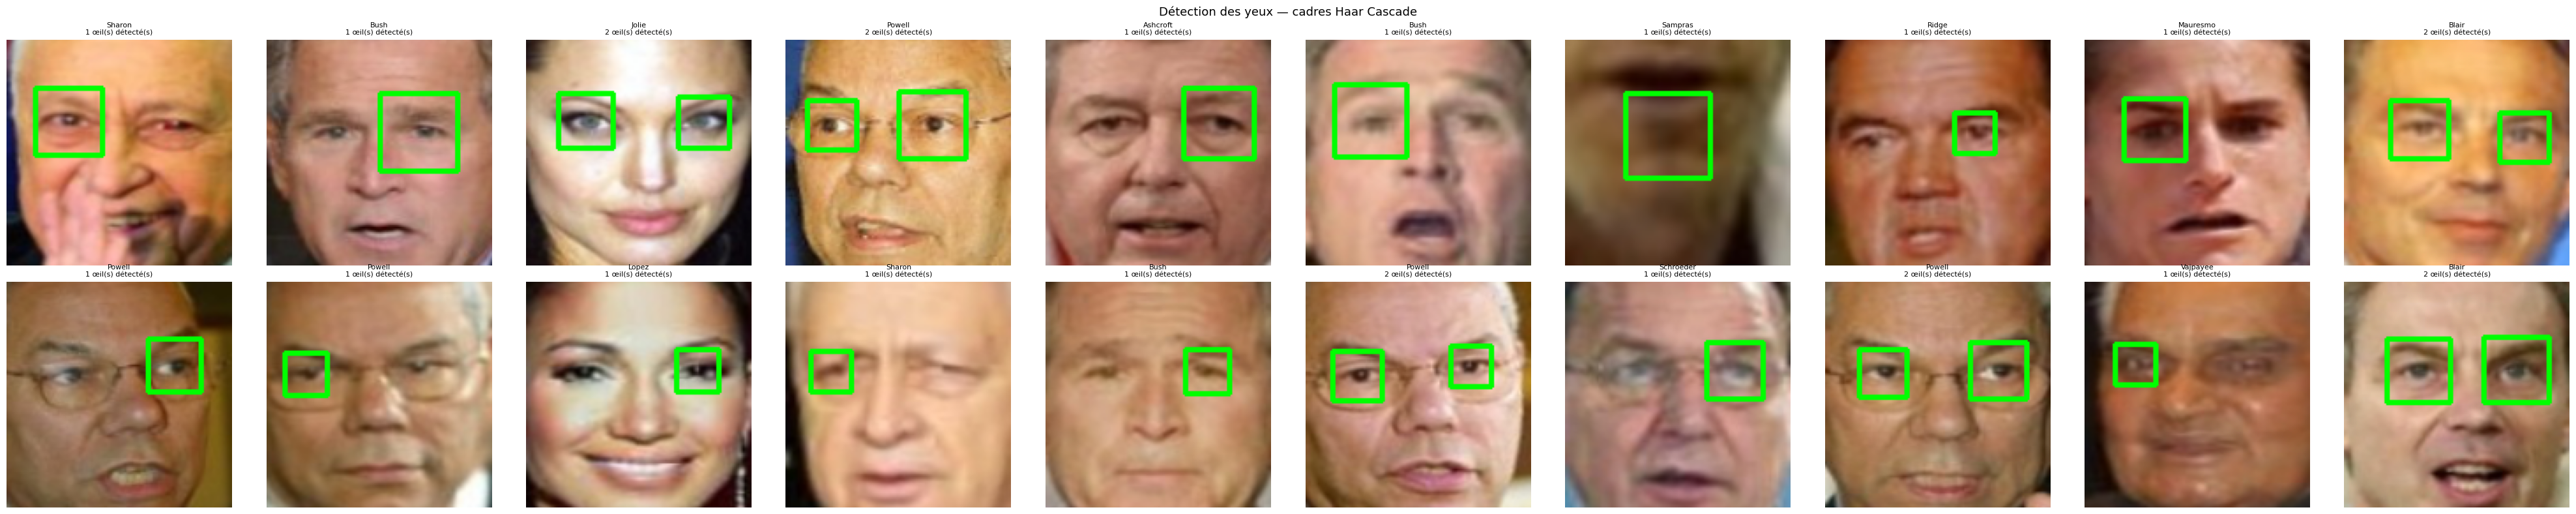

20 image(s) affichée(s) avec cadres de détection des yeux.


In [21]:
# ── Visualisation des cadres de détection des yeux ────────────────────────────
# Pour chaque image de démonstration, on dessine un rectangle vert autour de
# chaque œil détecté par le classifieur Haar afin de valider visuellement
# la détection avant l'alignement.

n_eye_demo = 20          # nombre d'images à afficher
shown      = 0
cols       = 10
rows       = (n_eye_demo + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()
fig.suptitle(
    "Détection des yeux — cadres Haar Cascade",
    fontsize=13
)

for idx in range(N):
    if shown >= n_eye_demo:
        break

    bgr = lfw_to_bgr(images[idx])
    face_crop, _ = detect_and_crop_face(bgr)
    if face_crop is None:
        continue

    face_crop = cv2.resize(face_crop, (128, 128))
    gray_face = cv2.cvtColor(face_crop, cv2.COLOR_BGR2GRAY)

    eyes = eye_cascade.detectMultiScale(
        gray_face,
        scaleFactor=1.3,
        minNeighbors=5,
        minSize=(20, 20)
    )

    if len(eyes) == 0:
        continue

    # Draw green rectangles around each detected eye
    vis = face_crop.copy()
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(vis, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)

    n_eyes = len(eyes)
    ax = axes[shown]
    ax.imshow(bgr_to_rgb(vis))
    ax.set_title(
        f"{names[labels[idx]].split()[-1]}\n{n_eyes} œil(s) détecté(s)",
        fontsize=8
    )
    ax.axis('off')
    shown += 1

# Hide unused axes
for ax in axes[shown:]:
    ax.axis('off')

plt.tight_layout()
plt.show()
print(f"{shown} image(s) affichée(s) avec cadres de détection des yeux.")


### 2f. Réduction du bruit et correction de l'éclairage

Deux techniques complémentaires :
- **Flou Gaussien** (`cv2.GaussianBlur`) : réduit le bruit haute fréquence (bruit de capteur).
- **CLAHE** (*Contrast Limited Adaptive Histogram Equalization*) : améliore le contraste localement et rend les images plus robustes aux variations d'éclairage.

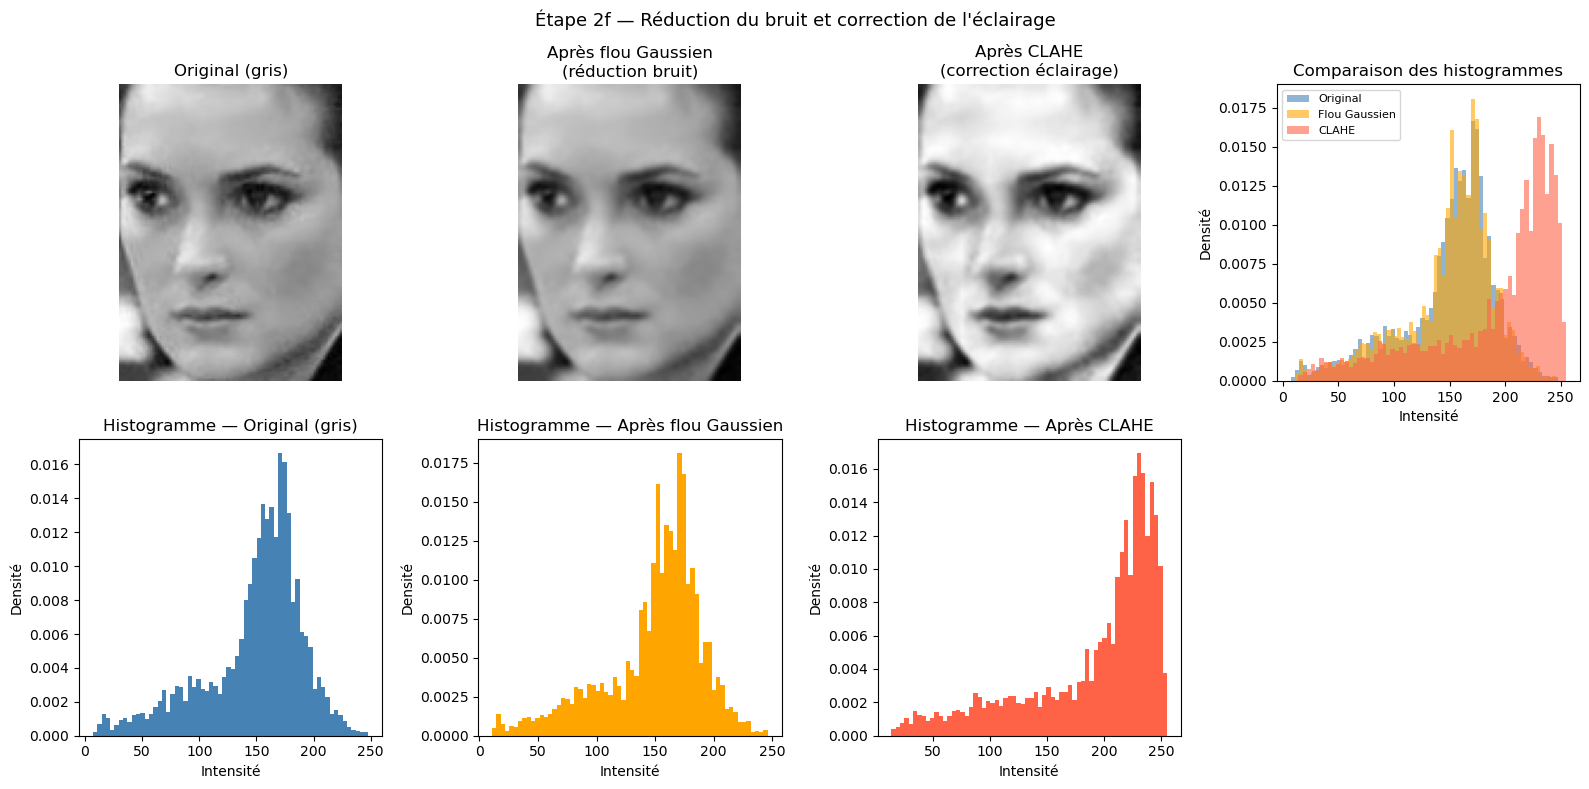

In [17]:
# ── Réduction du bruit : flou Gaussien ───────────────────────────────────────
# Kernel 3×3, σ déterminé automatiquement par OpenCV.
demo_denoised = cv2.GaussianBlur(demo_gray, (3, 3), 0)

# ── Correction de l'éclairage : CLAHE ────────────────────────────────────────
# clipLimit=2.0 : limite l'amplification du contraste pour éviter de
# créer des artefacts dans les zones uniformes.
# tileGridSize=(8,8) : la grille de tuiles sur laquelle CLAHE est appliqué.
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
demo_equalized = clahe.apply(demo_denoised)


fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Étape 2f — Réduction du bruit et correction de l'éclairage", fontsize=13)

imgs_to_show = [
    (demo_gray,      "Original (gris)"),
    (demo_denoised,  "Après flou Gaussien\n(réduction bruit)"),
    (demo_equalized, "Après CLAHE\n(correction éclairage)"),
    (None,           None),  # placeholder pour l'histogramme comparatif
]

for col, (img, title) in enumerate(imgs_to_show[:3]):
    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].set_title(title)
    axes[0, col].axis('off')

# Histogrammes correspondants
for col, (img, title) in enumerate(imgs_to_show[:3]):
    axes[1, col].hist(img.ravel(), bins=64, density=True,
                      color=['steelblue', 'orange', 'tomato'][col],
                      edgecolor='none')
    axes[1, col].set_title(f"Histogramme — {title.split(chr(10))[0]}")
    axes[1, col].set_xlabel("Intensité")
    axes[1, col].set_ylabel("Densité")

# Comparaison des 3 histogrammes dans la même figure
for img, label, color in [
    (demo_gray,      'Original',       'steelblue'),
    (demo_denoised,  'Flou Gaussien',   'orange'),
    (demo_equalized, 'CLAHE',           'tomato'),
]:
    axes[0, 3].hist(img.ravel(), bins=64, density=True,
                    alpha=0.6, label=label, color=color, edgecolor='none')
axes[0, 3].set_title("Comparaison des histogrammes")
axes[0, 3].set_xlabel("Intensité")
axes[0, 3].set_ylabel("Densité")
axes[0, 3].legend(fontsize=8)

axes[1, 3].axis('off')  # cellule vide



plt.tight_layout()
plt.show()

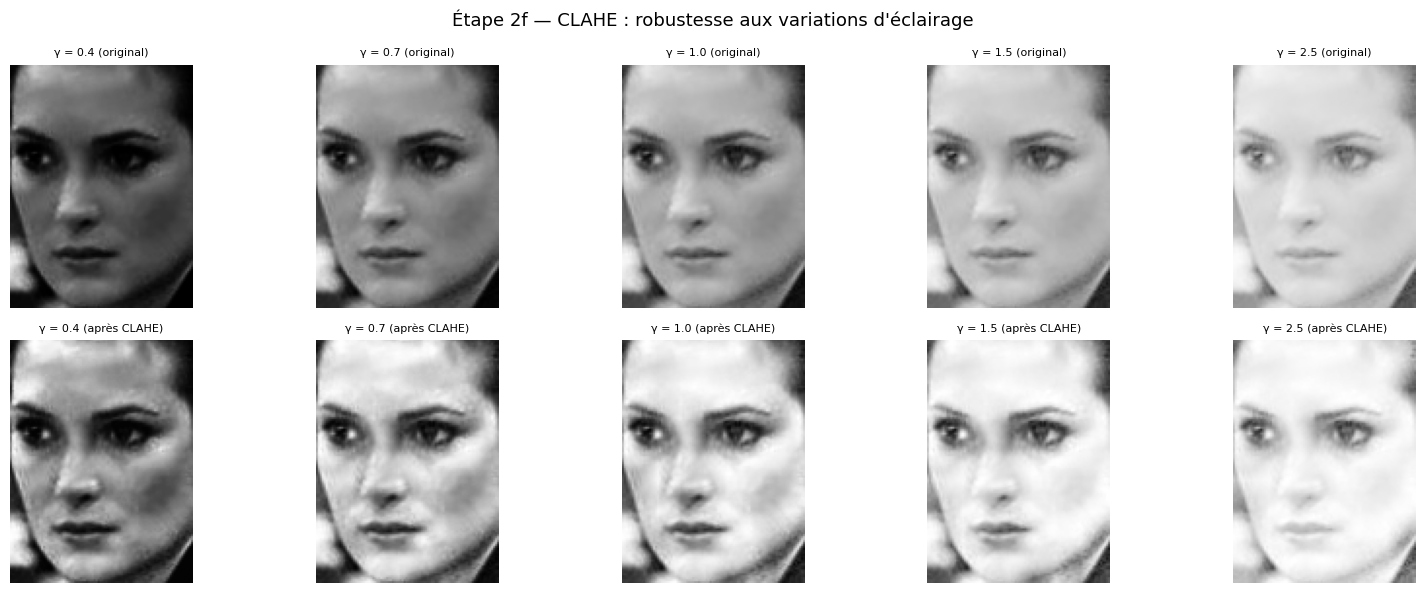

In [18]:
# ── Démonstration sur des images à éclairage variable ─────────────────────────
# On simule des conditions d'éclairage différentes en modifiant la luminosité.

def simulate_lighting(gray_img, gamma):
    """Simule un éclairage différent via une correction gamma."""
    lut = np.array([((i / 255.0) ** (1.0 / gamma)) * 255
                    for i in range(256)], dtype=np.uint8)
    return cv2.LUT(gray_img, lut)

gammas = [0.4, 0.7, 1.0, 1.5, 2.5]  # < 1 : plus sombre ; > 1 : plus clair

fig, axes = plt.subplots(2, len(gammas), figsize=(16, 6))
fig.suptitle("Étape 2f — CLAHE : robustesse aux variations d'éclairage", fontsize=13)

for col, gamma in enumerate(gammas):
    img_lit = simulate_lighting(demo_gray, gamma)
    img_eq  = clahe.apply(img_lit)

    axes[0, col].imshow(img_lit, cmap='gray', vmin=0, vmax=255)
    axes[0, col].set_title(f"γ = {gamma} (original)", fontsize=8)
    axes[0, col].axis('off')

    axes[1, col].imshow(img_eq, cmap='gray', vmin=0, vmax=255)
    axes[1, col].set_title(f"γ = {gamma} (après CLAHE)", fontsize=8)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()

---
## Pipeline complet — Résumé visuel

On applique le pipeline de bout en bout sur quelques images et on affiche chaque étape côte à côte.

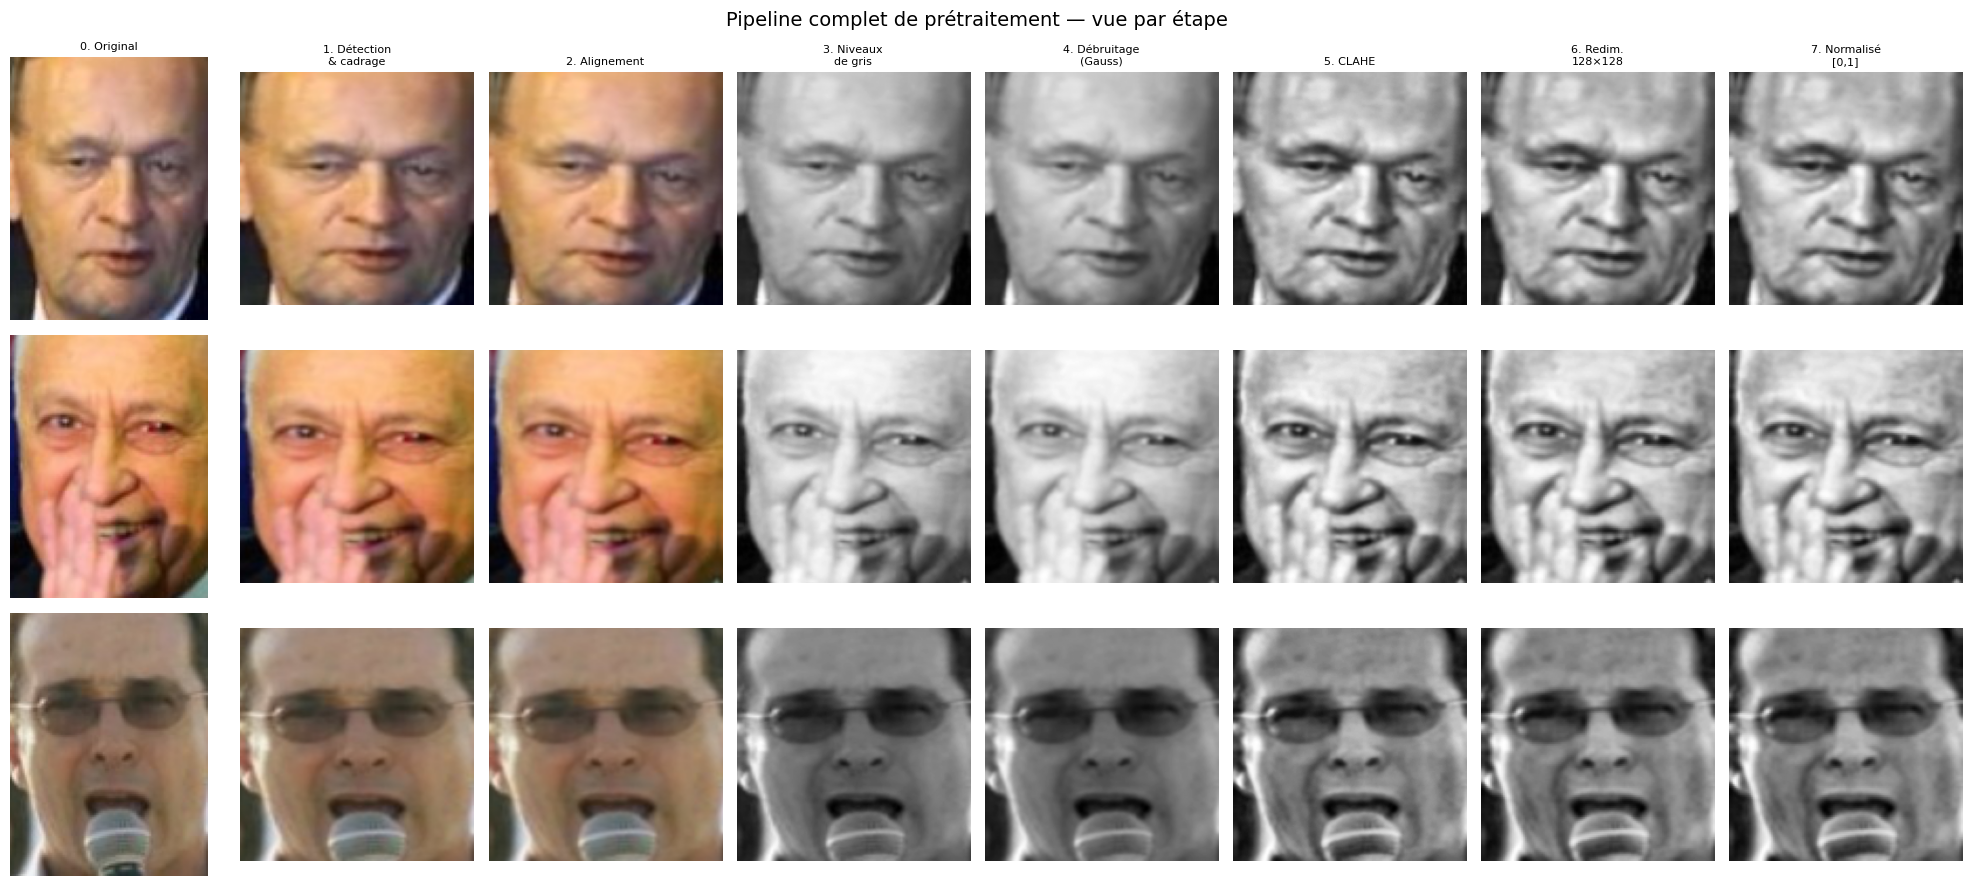

In [19]:
def full_pipeline(bgr_img, target_size=(128, 128)):
    """
    Pipeline complet de prétraitement :
      1. Détection et recadrage du visage (Haar Cascade)
      2. Alignement (détection des yeux)
      3. Conversion en niveaux de gris
      4. Réduction du bruit (flou Gaussien)
      5. Correction de l'éclairage (CLAHE)
      6. Redimensionnement
      7. Normalisation

    Retourne un dict avec l'image à chaque étape, ou None si aucun visage.
    """
    steps = {'0_original': bgr_to_rgb(bgr_img)}

    # Étape 1 : détection
    face, bbox = detect_and_crop_face(bgr_img)
    if face is None:
        return None
    face = cv2.resize(face, (200, 200))
    steps['1_detection'] = bgr_to_rgb(face)

    # Étape 2 : alignement
    aligned = align_face(face, eye_cascade)
    steps['2_alignement'] = bgr_to_rgb(aligned)

    # Étape 3 : niveaux de gris
    gray = cv2.cvtColor(aligned, cv2.COLOR_BGR2GRAY)
    steps['3_gris'] = gray

    # Étape 4 : débruitage
    denoised = cv2.GaussianBlur(gray, (3, 3), 0)
    steps['4_debruitage'] = denoised

    # Étape 5 : CLAHE
    clahe_eq = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    equalized = clahe_eq.apply(denoised)
    steps['5_clahe'] = equalized

    # Étape 6 : redimensionnement
    resized = cv2.resize(equalized, target_size)
    steps['6_redim'] = resized

    # Étape 7 : normalisation
    normalized = resized.astype(np.float32) / 255.0
    steps['7_normalise'] = normalized

    return steps


# ── Affichage du pipeline sur 3 identités différentes ────────────────────────
step_labels = [
    "0. Original", "1. Détection\n& cadrage", "2. Alignement",
    "3. Niveaux\nde gris", "4. Débruitage\n(Gauss)",
    "5. CLAHE", "6. Redim.\n128×128", "7. Normalisé\n[0,1]",
]

selected = []
for idx in range(N):
    bgr = lfw_to_bgr(images[idx])
    result = full_pipeline(bgr)
    if result is not None:
        selected.append((idx, result))
    if len(selected) == 3:
        break

n_steps = len(step_labels)
fig, axes = plt.subplots(3, n_steps, figsize=(20, 9))
fig.suptitle("Pipeline complet de prétraitement — vue par étape", fontsize=14)

for row, (idx, result) in enumerate(selected):
    for col, (key, img) in enumerate(result.items()):
        ax = axes[row, col]
        cmap = None if img.ndim == 3 else 'gray'
        ax.imshow(img, cmap=cmap)
        if row == 0:
            ax.set_title(step_labels[col], fontsize=8)
        if col == 0:
            ax.set_ylabel(names[labels[idx]], fontsize=8, rotation=0, labelpad=70, va='center')
        ax.axis('off')

plt.tight_layout()
plt.show()

---
## Bilan

| Étape | Technique | Bibliothèque |
|-------|-----------|-------------|
| Acquisition | Labeled Faces in the Wild (LFW) | `scikit-learn` |
| Détection | Viola-Jones / Haar Cascade | `OpenCV` |
| Cadrage | Boîte englobante + marge | `OpenCV` / `NumPy` |
| Alignement | Détection des yeux + rotation affine | `OpenCV` |
| Niveaux de gris | Pondération perceptuelle RGB→Y | `OpenCV` |
| Débruitage | Filtre Gaussien (3×3) | `OpenCV` |
| Éclairage | CLAHE (clipLimit=2, tile 8×8) | `OpenCV` |
| Redimensionnement | Interpolation bilinéaire → 128×128 | `OpenCV` |
| Normalisation | Division par 255 → float32 [0,1] | `NumPy` |

Les images prétraitées sont prêtes à être utilisées en entrée des extracteurs de features (LBP, HOG, Haar ou DeepFace) définis dans les modules `features/` du projet.